In [23]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importing dataset from Sql :

In [24]:
conn = sqlite3.connect(r'C:\Users\LENOVO\Project-2-\SQL\imdb_universe.db')
query = "SELECT * FROM movies;"

df = pd.read_sql(query , conn)


In [25]:
df

,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,The Shawshank Redemption,1994,A,142 min,Drama,9.3,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,28341469.0
1,The Godfather,1972,A,175 min,"Crime, Drama",9.2,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,134966411.0
2,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,534858444.0
3,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,57300000.0
4,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,4360000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,A,115 min,"Comedy, Drama, Romance",7.6,76.0,Blake Edwards,Audrey Hepburn,George Peppard,Patricia Neal,Buddy Ebsen,166544,23530892.0
996,Giant,1956,G,201 min,"Drama, Western",7.6,84.0,George Stevens,Elizabeth Taylor,Rock Hudson,James Dean,Carroll Baker,34075,23530892.0
997,From Here to Eternity,1953,Passed,118 min,"Drama, Romance, War",7.6,85.0,Fred Zinnemann,Burt Lancaster,Montgomery Clift,Deborah Kerr,Donna Reed,43374,30500000.0
998,Lifeboat,1944,Passed,97 min,"Drama, War",7.6,78.0,Alfred Hitchcock,Tallulah Bankhead,John Hodiak,Walter Slezak,William Bendix,26471,23530892.0


### 1. Top 10 most earning movies Directors

In [26]:
data = df.groupby('Director')['Gross'].max().sort_values(ascending=False).head(10).reset_index()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11244\2339154908.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x='Director', y='Gross', palette='magma')


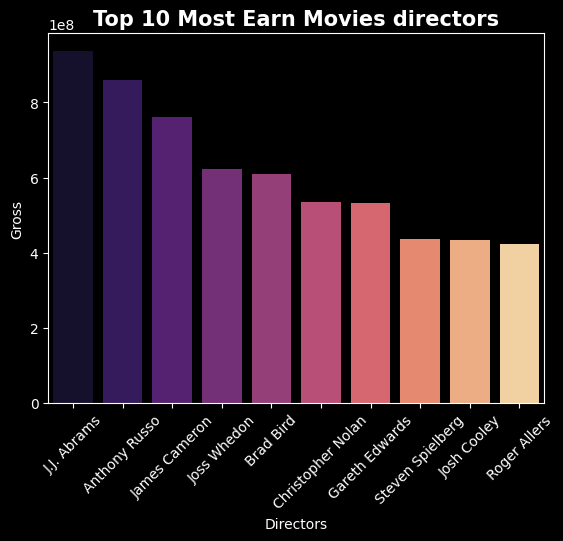

In [27]:
sns.barplot(data=data, x='Director', y='Gross', palette='magma')
plt.style.use('dark_background')
plt.xticks(rotation=45)
plt.title('Top 10 Most Earn Movies directors', fontweight='bold', fontsize=15)
plt.xlabel('Directors')
plt.ylabel('Gross')
plt.show()

### 2. Total Release Movies Every year

In [28]:
df.groupby('Director')['Gross'].sum().sort_values(ascending=False).head(10)



Director
Steven Spielberg     2.478133e+09
Anthony Russo        2.205039e+09
Christopher Nolan    1.937454e+09
James Cameron        1.748237e+09
Peter Jackson        1.597312e+09
J.J. Abrams          1.423171e+09
Brad Bird            1.099628e+09
Robert Zemeckis      1.049446e+09
David Yates          9.789537e+08
Pete Docter          9.629130e+08
Name: Gross, dtype: float64

In [29]:
df.columns

Index(['Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre',
       'IMDB_Rating', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3',
       'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11244\2681026686.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(data=movies_per_year, x='Released_Year', y='Series_Title', palette='magma')


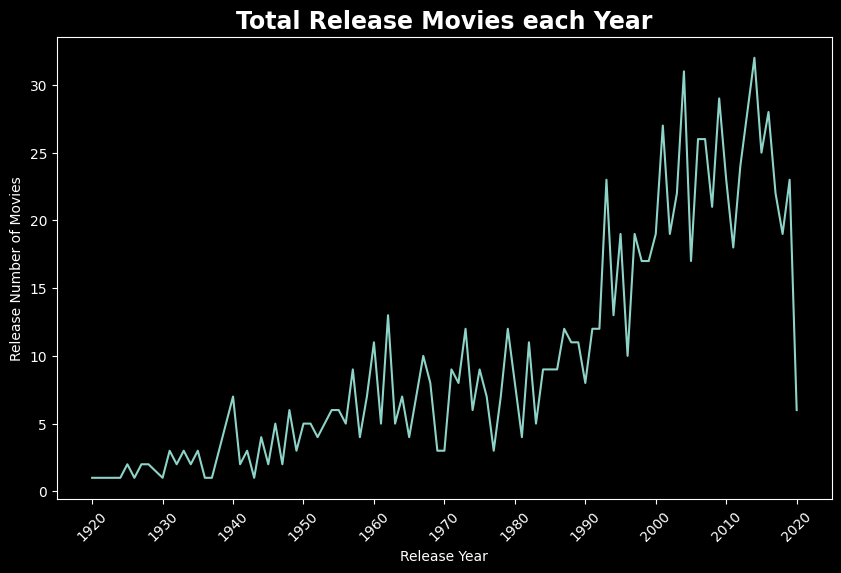

In [74]:
plt.figure(figsize=(10, 6))
df['Released_Year'] = pd.to_numeric(df['Released_Year'], errors='coerce')

movies_per_year = df['Released_Year'].value_counts().sort_values().reset_index()
movies_per_year.columns = ['Released_Year','Series_Title']


min_year = int(df['Released_Year'].min())
max_year = int(df['Released_Year'].max())
sns.lineplot(data=movies_per_year, x='Released_Year', y='Series_Title', palette='magma')

plt.xticks(range(min_year, max_year + 1, 10), rotation=45)

plt.title('Total Release Movies each Year', fontsize='17', fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Release Number of Movies')
plt.show()

### 3. Top 10 most Voted movies 

In [48]:
datas = df.groupby(['Series_Title','Director'])['No_of_Votes'].max().sort_values(ascending=False).head(10).reset_index()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11244\1146517034.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=datas, y='Series_Title', x='No_of_Votes', palette='magma')


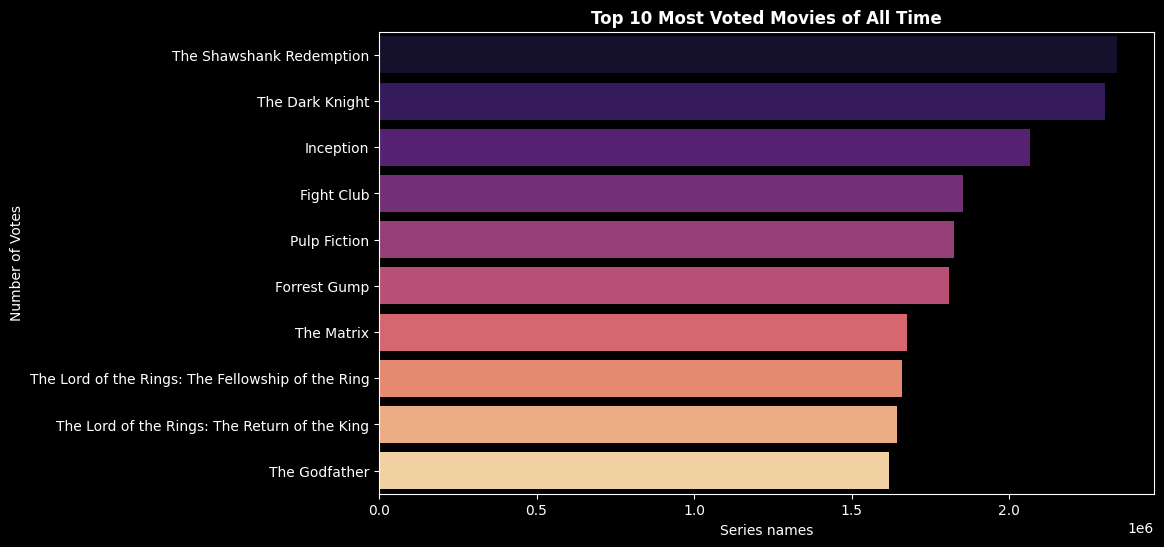

<Figure size 1200x800 with 0 Axes>

In [66]:
plt.figure(figsize=(10, 6))
sns.barplot(data=datas, y='Series_Title', x='No_of_Votes', palette='magma')

plt.title('Top 10 Most Voted Movies of All Time', fontweight='bold')
plt.xlabel('Series names')
plt.ylabel('Number of Votes')
plt.figure(figsize=(12, 8))
plt.show()

### 4. Distrubution of IMDB rating 

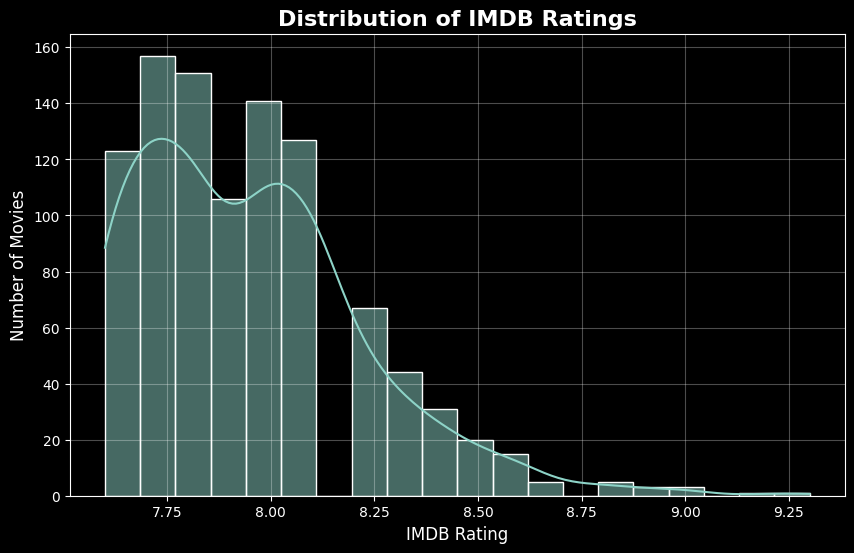

In [65]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='IMDB_Rating', bins=20, kde=True)

plt.title('Distribution of IMDB Ratings', fontsize=16, fontweight='bold')
plt.xlabel('IMDB Rating', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

### 5. Relationship Between Runtime and Gross Revenue

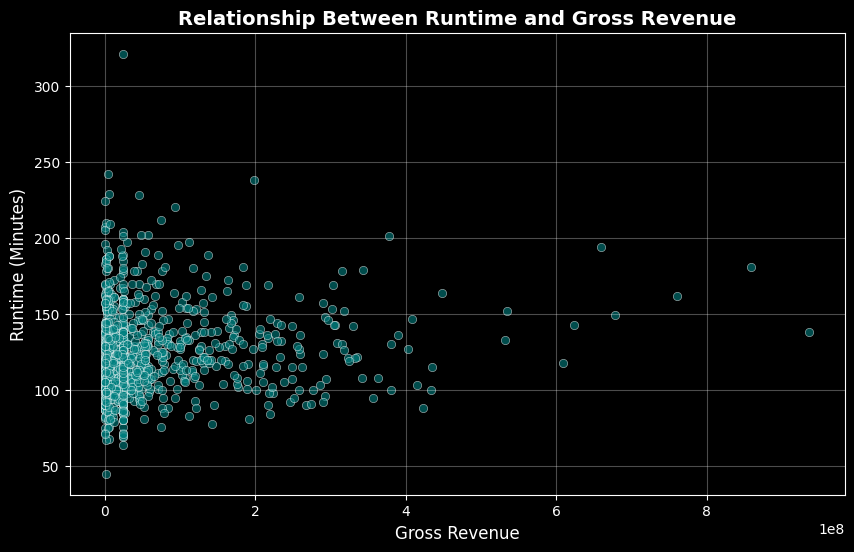

In [71]:

df['Runtime'] = df['Runtime'].astype(str).str.replace(' min', '').astype(int)

plt.figure(figsize=(10, 6))

sns.scatterplot(y=df['Runtime'], x=df['Gross'], alpha=0.6, color='teal')

plt.title('Relationship Between Runtime and Gross Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Gross Revenue', fontsize=12)
plt.ylabel('Runtime (Minutes)', fontsize=12)

plt.grid(True, alpha=0.3)
plt.show()

In [72]:
df.to_sql('movies', conn, if_exists='replace', index=False)

1000

In [73]:
conn.close()